In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import rc
import seaborn as sns
from datetime import datetime, timedelta

# 1. 데이터 분석

## 1-1 데이터 수집 및 전처리

In [ ]:
FULL = ("2024-03-15", "2026-05-29")

raw = pd.read_csv("/Users/shinwoook/Desktop/BNAI_stock.csv")
raw.columns = [c.strip() for c in raw.columns]

# 날짜 먼저 파싱 -> 정렬 -> 구간 자르기
raw["date"] = pd.to_datetime(raw["Date"], format="%m/%d/%Y")
raw = raw.sort_values("date").set_index("date") # sort_values("date"):오름차순 정렬, set_index("date"):날짜를 행 인덱스로 올림
stock = raw.loc[FULL[0]:FULL[1]].copy()

# 자른 뒤에 숫자 변환
for src, dst in [("Close/Last", "close"), ("Open", "open"), ("High", "high"), ("Low", "low")]:
  stock[dst] = pd.to_numeric(stock[src].astype(str).str.replace(r"[$,]", "", regex=True)) # [$,]:정규식($or,), regex=True로 해야 정규식 적용
stock["volume"] = pd.to_numeric(stock["Volume"].astype(str).str.replace(",", "", regex=False))
stock = stock[["open", "high", "low", "close", "volume"]]

# 파생 변수
stock["return"] = stock["close"].pct_change(fill_method=None) # 단순 수익률
stock["log_return"] = np.log(stock["close"]).diff() # 로그수익률
stock["volatility"] = stock["return"].rolling(5).std() # 변동성

stock.to_csv("stock_BNAI_clean.csv")

In [3]:
stock_data = pd.read_csv("./stock_BNAI_clean.csv", index_col=0, parse_dates=True)
stock_data

,open,high,low,close,volume,return,log_return,volatility
date,,,,,,,,
2024-03-15,58.50,116.4000,56.500,105.600,35374.0,NaN,NaN,NaN
2024-03-18,144.50,197.5000,125.100,137.500,56596.0,0.302083,0.263966,NaN
2024-03-19,117.30,129.8000,83.100,124.900,12945.0,-0.091636,-0.096110,NaN
2024-03-20,105.30,133.8000,105.300,122.800,3962.0,-0.016813,-0.016956,NaN
2024-03-21,128.10,135.0000,106.701,111.250,8562.0,-0.094055,-0.098777,NaN
...,...,...,...,...,...,...,...,...
2026-05-22,19.15,19.5800,18.430,18.505,165232.0,-0.036700,-0.037390,0.019776
2026-05-26,18.07,20.1000,16.300,19.540,347526.0,0.055931,0.054423,0.041140
2026-05-27,18.25,18.4299,15.500,15.540,372544.0,-0.204708,-0.229046,0.096537


In [4]:
# 검색량 데이터
trends = pd.read_csv("/Users/shinwoook/Desktop/Goole_Trends.csv", skiprows=2)
trends.head()

,주,BNAI: (미국)
0,2024-03-10,11
1,2024-03-17,18
2,2024-03-24,12
3,2024-03-31,13
4,2024-04-07,12


In [5]:
# 실행 전 이전 셀 반드시 먼저 실행
trends.columns = ["date", "search_volume"]
trends["date"] = pd.to_datetime(trends["date"])
trends = trends.set_index("date").sort_index()

trends["log_search"] = np.log1p(trends["search_volume"]) # 로그 변환
trends["dlog_search"] = trends["log_search"].diff() 
# 1차 차분, diff():직전 행과의 차이, Granger검정 & VAR은 정상 시계열을 전제함
trends = trends.loc["2024-03-17":]
trends.to_csv("trends_clean.csv")

In [6]:
search_data = pd.read_csv("./trends_clean.csv", index_col=0, parse_dates=True)
search_data

,search_volume,log_search,dlog_search
date,,,
2024-03-17,18,2.944439,0.459532
2024-03-24,12,2.564949,-0.379490
2024-03-31,13,2.639057,0.074108
2024-04-07,12,2.564949,-0.074108
2024-04-14,11,2.484907,-0.080043
...,...,...,...
2026-04-26,16,2.833213,-0.211309
2026-05-03,14,2.708050,-0.125163
2026-05-10,15,2.772589,0.064539


In [7]:
print(len(stock_data))
print(len(search_data))

553
115


## 1-2 추세확인

* 주가 vs 검색량

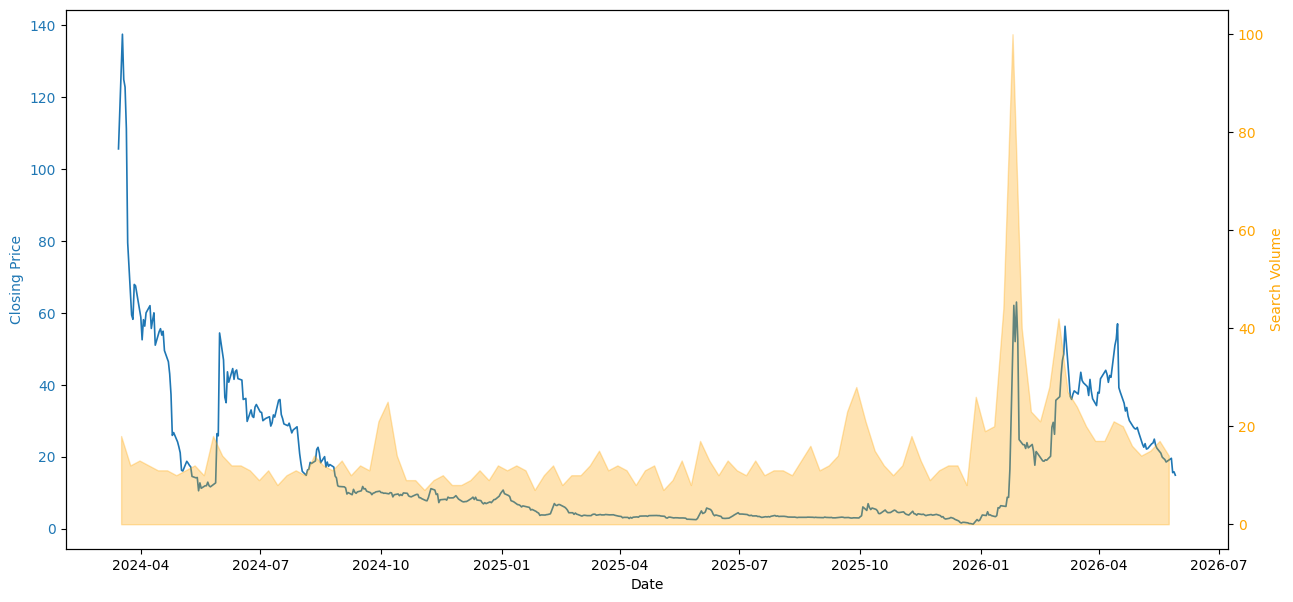

In [8]:
fig, ax = plt.subplots(figsize=(15, 7))
ax.plot(stock_data.index, stock_data["close"], color="#1f77b4", lw=1.2) # 종가
ax.set_ylabel("Closing Price", color="#1f77b4")
ax.tick_params(axis="y", labelcolor="#1f77b4")
ax.set_xlabel("Date")

ax2 = ax.twinx()
ax2.fill_between(search_data.index, search_data["search_volume"], color="orange", alpha=0.3)
ax2.set_ylabel("Search Volume", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")

plt.show()


## 1-3 검색량과 변동성의 관계

* 먼저 일별 변동성, 수익률, 거래량을 다운샘플링

In [9]:
weekly = pd.DataFrame({
    "volatility" : stock_data["return"].resample("W-SAT").std(),
    "return" : stock_data["close"].resample("W-SAT").last().pct_change(fill_method=None),
    "volume" : stock_data["volume"].resample("W-SAT").sum()
})

t = search_data.copy()
t.index = t.index + pd.Timedelta(days=6)
weekly = weekly.join(t, how="inner").dropna()
# join:인덱스 기준으로 두 df을 옆으로 붙임, how="inner":양쪽에 모두 존재하는 날짜만 남기라는 뜻

print(len(weekly))

115


In [10]:
weekly

,volatility,return,volume,search_volume,log_search,dlog_search
date,,,,,,
2024-03-23,0.214082,-0.247159,96921.0,18,2.944439,0.459532
2024-03-30,0.172234,-0.150943,41822.0,12,2.564949,-0.379490
2024-04-06,0.103631,-0.111111,30476.0,13,2.639057,0.074108
2024-04-13,0.090849,-0.150000,21916.0,12,2.564949,-0.074108
2024-04-20,0.064838,-0.029412,9057.0,11,2.484907,-0.080043
...,...,...,...,...,...,...
2026-05-02,0.030150,-0.105596,1702942.0,16,2.833213,-0.211309
2026-05-09,0.065418,-0.170950,1813717.0,14,2.708050,-0.125163
2026-05-16,0.053617,0.003594,1663165.0,15,2.772589,0.064539


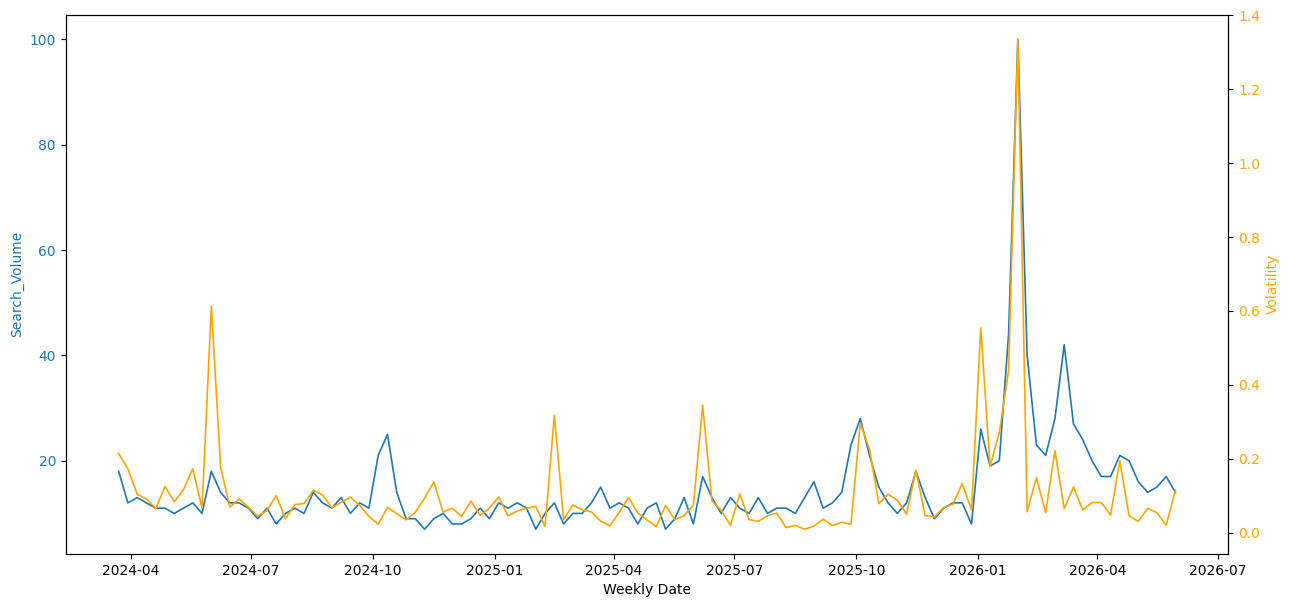

In [11]:
fig, ax = plt.subplots(figsize=(15,7))
ax.plot(weekly.index, weekly["search_volume"], color='#1f77b4', lw=1.2)
ax.set_ylabel("Search_Volume", color='#1f77b4')
ax.tick_params(axis="y", labelcolor='#1f77b4')
ax.set_xlabel("Weekly Date")

ax2 = ax.twinx()
ax2.plot(weekly.index, weekly["volatility"], color='orange', lw=1.2)
ax2.set_ylabel("Volatility", color='orange')
ax2.tick_params(axis="y", labelcolor='orange')

plt.show()

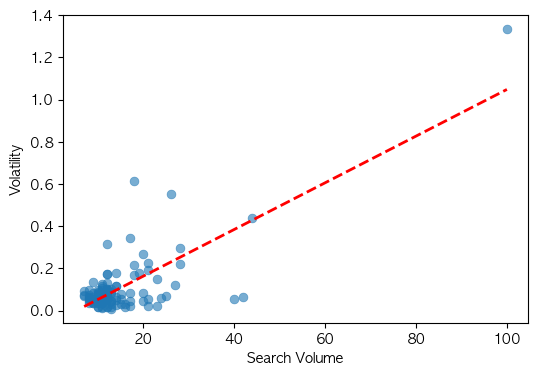

In [176]:
x = weekly["search_volume"]
y = weekly["volatility"]

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(x, y,
           s = 40,
           color = "#1f77b4",
           alpha = 0.6,
           lw = 0.5)
ax.set_xlabel("Search Volume")
ax.set_ylabel("Volatility")

m, b = np.polyfit(x, y, 1) # 기울기, 절편
xs = np.linspace(x.min(), x.max(), 100)
ax.plot(xs, m * xs + b, color='red', lw=2, linestyle="--")
plt.show()

\- 양의 상관관계 관찰 및 이상치 발견

In [13]:
# spearman(스피어만 상관계수)
p = weekly["search_volume"].corr(weekly["volatility"]) # 피어슨 상관계수
s = weekly["search_volume"].corr(weekly["volatility"], method="spearman") # 스피어만 상관계수
print("Pearson : {:.5f}".format(p))
print("Spearman : {:.5f}".format(s))

Pearson : 0.76186
Spearman : 0.25512


두 값이 크게 다르므로 이상치 의존이 가능성이 있음

In [14]:
weekly[weekly["search_volume"] >= 80]

,volatility,return,volume,search_volume,log_search,dlog_search
date,,,,,,
2026-01-31,1.335537,0.50182,74190078.0,100,4.615121,0.808458


In [15]:
w = weekly[weekly.index != "2026-01-31"]
p2 = w["search_volume"].corr(w["volatility"])
print("Pearson : {}".format(p2))

Pearson : 0.4136591680146819


\- 산점도에서 관측치 대부분이 저검색량-저변동성 영역에 밀집한 반면, 2026년 1월 급증 주 1건만 우상단에 고립되어있다.
해당 관측치를 제외하면 Pearson상관은 0.7에서 0.4로 하락한다. 
따라서 검색량-변동성은 상시적 관계가 아니라 단일 이벤트에 의해 형성된 것으로, 본 종목에서 검색량은 평상시 변동성에 대한 정보를
거의 갖지 않는것으로 판단된다.

In [16]:
# 분위별 평균

weekly["q"] = pd.qcut(weekly["search_volume"], 5, labels=False, duplicates="drop") + 1
# pd.qcut:값을 크기 순으로 정렬해 같은 개수씩 그룹으로 나눔(5개 그룹), 즉 23주가 한 그룹
# 1분위가 검색량이 가장 낮은 23주, 5분위가 검색량이 가장 높은 23주, 
# *duplicates="drop":경계값이 겹칠 때 에러대신 그룹 수를 줄임, 검색량에 같은 값이 많으면 필요

print(weekly.groupby(pd.qcut(weekly["search_volume"], 5, labels=False, duplicates="drop")+1)["volatility"].mean().round(4))
# df.groupby("기준열")["대상열"].집계함수() : 데이터를 기준에 따라 그룹으로 나눈 뒤, 각 그룹마다 계산하는 함수

search_volume
1    0.0619
2    0.0631
3    0.0972
4    0.0728
5    0.2372
Name: volatility, dtype: float64


\- 5분위에서만 급증으로 문턱형임을 확인할 수 있음, 즉 검색량과 변동성은 상시 연동되지 않고,
   검색량이 일정 수준을 넘는 이벤트 국면에서만 함께 움직인다는 것을 의미한다. 

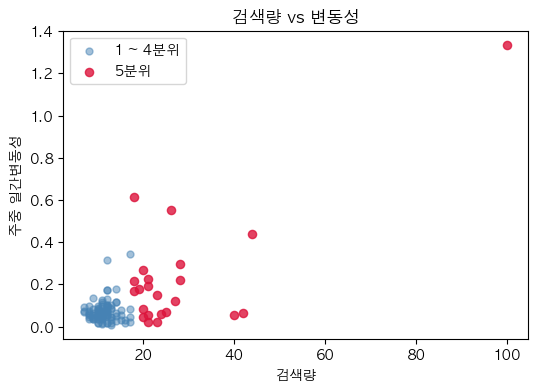

In [17]:
# 5분위에 속하는 데이터가 어떻게 분포하는지 산점도로 확인
plt.rc("font", family="AppleGothic")
top = weekly["q"] == 5
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(weekly.loc[~top, "search_volume"], weekly.loc[~top, "volatility"], # .loc[행 조건, 열 선택]
           alpha=0.5, s=25, color="steelblue", label="1 ~ 4분위")
ax.scatter(weekly.loc[top, "search_volume"], weekly.loc[top, "volatility"],
           alpha=0.8, s=35, color="crimson", label="5분위")
ax.set(xlabel="검색량", ylabel="주중 일간변동성", title="검색량 vs 변동성")
ax.legend()
plt.show()

\- 실제로 5분위에 해당하는 데이터가 우측에 위치하는 것을 확인할 수 있다.
1 ~ 4분위 데이터들은 완전히 뭉쳐있는것을 확인할 수 있다. 변동성 0 ~ 0.2구간에 대부분 밀집해있고 x축 방향으로 퍼지지 않는다.
이 구간에서는 검색량 변동성이 거의 없는 수준이므로 검색량과 변동성의 관계를 논할 수 없다.

\- 산점도는 검색량-변동성 관계가 단조적이지 않음을 보여준다. 1~4분위는 좁은 영역에 밀집해 변별력이 없고, 5분위 내부에서도 
유사한 검색량 수준에서 변동성이 0.02 ~ 0.61로 크게 흩어진다. 특히 검색량 40 ~ 45인 3개 주의 변동성은 최하위 분포와 유사하다. 
관측된 양의 상관은 검색량 100, 변동성 1.33인 단일 관측치에 의해 형성된 것으로, 본 종목에서 검색량은 평상시 변동성에 대한 정보를 갖지 않는다고 판단된다. 

\- 검색량 - 변동성의 단일 이벤트 의존을 확인할 수 있다.

In [18]:
# 추가 검색량 40 ~ 45인 주 확인
k = (weekly["search_volume"] >= 40) & (weekly["search_volume"] <= 45)
weekly[k]

,volatility,return,volume,search_volume,log_search,dlog_search,q
date,,,,,,,
2026-01-24,0.438847,1.595276,95515887.0,44,3.806662,0.762140,5
2026-02-07,0.056255,-0.092929,19674378.0,40,3.713572,-0.901548,5
2026-03-07,0.064199,0.577074,10712182.0,42,3.761200,0.393904,5


\- 검색량이 44인 주는 실제로 폭등한 주와 거의 비슷한 시점이다. 실제로 변동성이 약 0.44로 두번째로 높으며, 주간 수익률이 약 159%로 역시 매우 높은것을 확인할 수 있다. 

\- 2/7에 주간수익률 -9%로 하락했지만, 3/7을 보면 0.06으로 낮은 일간 변동성과 함께 주간수익률이 57.7%로 크게 오른것을 확인할 수 있다. 이는 며칠에 걸쳐 꾸준히 상승한 국면이다. 급등락 없이 추세적으로 올랐다는 신호이다. 다만 거래량은 시간이 지날수록 9,552만 → 1,967만 → 1,071만 주로 급감했다. 검색 관심은 유지되었으나 실제 거래는 위축되어, 검색 기반 관심 지표가 거래 활동을 대리하지 못하는 구간이 존재함을 시사한다.

\- 검색량 상위 3개 주(40~44)를 비교하면 주간 수익률이 각각 +159.5%, −9.3%, +57.7%로 방향과 크기가 모두 상이하다. 동일한 검색량 수준에서 상반된 결과가 관측되므로, 검색량 수준 자체는 후속 가격 움직임에 대한 정보를 갖지 않는다. 

\- 1월 급등 이후 주가는 상승한 가격대를 유지했으나 거래량은 9,552만 → 1,967만 → 1,071만 주로 급감했다. 반면 검색량은 44 → 40 → 42로 유지되어, 관심은 잔류하되 실제 거래는 크게 위축되는 괴리가 관찰된다. 이는 급등 이후 신규 매수세가 소진되고 유동성이 감소하는 국면으로, 검색 기반 관심 지표가 거래 활동을 대리하지 못할 수 있음을 시사한다.

# 2. 선행성 분석

## 2-1 교차상관분석

In [22]:
# weekly에 로그 수익률 추가
weekly["log_return"] = np.log(stock_data["close"].resample("W-SAT").last()).diff()
weekly["close"] = stock_data["close"].resample("W-SAT").last()
weekly

,volatility,return,volume,search_volume,log_search,dlog_search,q,log_return,close
date,,,,,,,,,
2024-03-23,0.214082,-0.247159,96921.0,18,2.944439,0.459532,5,-0.283901,79.500
2024-03-30,0.172234,-0.150943,41822.0,12,2.564949,-0.379490,3,-0.163629,67.500
2024-04-06,0.103631,-0.111111,30476.0,13,2.639057,0.074108,4,-0.117783,60.000
2024-04-13,0.090849,-0.150000,21916.0,12,2.564949,-0.074108,3,-0.162519,51.000
2024-04-20,0.064838,-0.029412,9057.0,11,2.484907,-0.080043,2,-0.029853,49.500
...,...,...,...,...,...,...,...,...,...
2026-05-02,0.030150,-0.105596,1702942.0,16,2.833213,-0.211309,4,-0.111598,26.850
2026-05-09,0.065418,-0.170950,1813717.0,14,2.708050,-0.125163,4,-0.187474,22.260
2026-05-16,0.053617,0.003594,1663165.0,15,2.772589,0.064539,4,0.003587,22.340


In [26]:
# dlog_search, log_return의 정상성 여부 확인을 위해 ADF검정
from statsmodels.tsa.stattools import adfuller

for c in ["close", "dlog_search", "log_return", "log_search", "search_volume"]:
    p = adfuller(weekly[c], autolag="AIC")[1]
    print("{} : {:.5f}".format(c, p))

close : 0.33290
dlog_search : 0.00000
log_return : 0.00000
log_search : 0.04474
search_volume : 0.03397


\- dlog_search, log_return의 p < 0.05이므로 정상성을 띤다고 볼 수 있다. log_search, search_volume 역시 p가 0.05보다 작지만 애매한 수치임을 확인할 수 있다.(결과가 애매할 경우 kpss함께 확인) 

\- 따라서 CCF확인은 dlog_search와 log_return으로 시행하겠다.

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


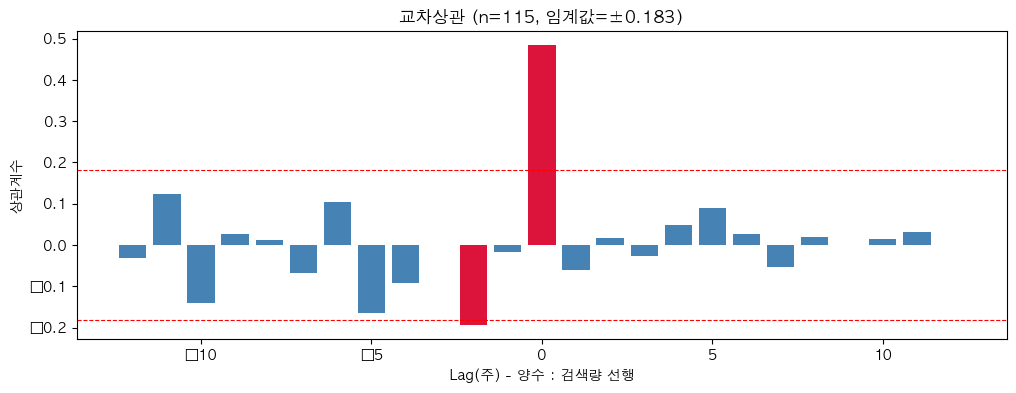

In [38]:
# 교차상관분석(CCF)
d = weekly[["dlog_search", "log_return"]]
lags = range(-12, 13)
ccf = [d["log_return"].corr(d["dlog_search"].shift(k)) for k in lags] # shift(k)가 k>0일 때 아래로 민다.
ci = 1.96 / np.sqrt(len(d))

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(list(lags), ccf, color=["crimson" if abs(c) > ci else "steelblue" for c in ccf])
ax.axhline(ci, color="red", ls="--", lw=0.8)
ax.axhline(-ci, color="red", ls="--", lw=0.8)
ax.set(xlabel="Lag(주) - 양수 : 검색량 선행", ylabel="상관계수", 
       title="교차상관 (n={}, 임계값=±{:.3f})".format(len(d), ci))
plt.show()

1. lag0에서만 강한 양의상관(0.49):

임계값 0.183을 크게 넘는 유일한 양수 시차. 검색량 변화와 수익률이 같은 주에 함께 움직인다는 의미

2. 양수 lag가 전부 유의하지 않음:

lag1 ~ 12가 모두 -0.06 ~ 0.09구간에 머물러 임계선 근처에도 못가는 것을 확인할 수 있음. 검색량이 수익률을 선행한다는 근거가 없음.

3. lag(-2)에서의 음의 상관(-0.19):

수익률이 검색량에 2주 선행. 하지만 12개의 시차 중 하나만 겨우 임계값을 넘긴 수준이라 다중검정으로 나올 수 있는 범위. 따라서 강한 주장의 근거로 쓰기에 약함.

\- 핵심은 lag0의 지배구조. 검색과 주가가 동시에 반응하는데 어느쪽도 앞서지 않는다면, 가장 자연스러운 설명은 뉴스나 공시같은 제3의 공통 요인이 둘을 동시에 움직였다는 것. 즉 검색량이 정보를 만들어내는게 아니라 정보에 반응하는 지표라는 뜻임을 확인할 수 있음

\- 교차상관은 lag0에서만 0.49로 임계값을 유의하게 초과하며, 양수 lag(검색량 선행)구간은 전 시차에서 비유의하다. 검색량 변화와 수익률은 동시점에서만 연동되며, 검색량이 수익률에 선행한다는 증거는 발견되지 않는다. lag(-2)에서 음의 상관이 관측되나 12개 음수 시차 중 단일 사례로, 다중검정을 고려하면 강한 근거로 보기 어렵다. 

In [51]:
# 참고
df = pd.DataFrame({"lag":list(lags), "corr":np.round(ccf, 4)})
print(df)
# to_string() : 전체 행을 생략없이 출력, index=False : 인덱스를 생략

df[abs(df["corr"]) > ci]

    lag    corr
0   -12 -0.0314
1   -11  0.1226
2   -10 -0.1406
3    -9  0.0269
4    -8  0.0131
5    -7 -0.0676
6    -6  0.1037
7    -5 -0.1653
8    -4 -0.0918
9    -3  0.0008
10   -2 -0.1944
11   -1 -0.0170
12    0  0.4842
13    1 -0.0611
14    2  0.0178
15    3 -0.0271
16    4  0.0495
17    5  0.0896
18    6  0.0258
19    7 -0.0534
20    8  0.0192
21    9 -0.0000
22   10  0.0154
23   11  0.0316
24   12 -0.0006


,lag,corr
10,-2,-0.1944
12,0,0.4842


In [ ]:
# lag0의 이상치 제거 후 : 동시점 상관이 단일 이벤트에 의존한 것인가?
d2 = d.drop(d["dlog_search"].idxmax())
print(f"전체      {d['log_return'].corr(d['dlog_search']):.3f}")
print(f"최대 제외  {d2['log_return'].corr(d['dlog_search']):.3f}")
print(f"Spearman {d['log_return'].corr(d['dlog_search'], method='spearman'):.3f}")

전체      0.484
최대 제외  0.412
Spearman 0.262


\- 마지막 정리 : lag0 상관 0.48은 최대 관측치 제외 후에도 0.412로 유지되어 동시점 연동 자체는 단일 이벤트에 의존하지 않는 견고한 관계로 판단된다. 다만 Spearman상관이 0.26에 그쳐 관계가 대규모 변동 구간에 집중됨을 시사하며, 이는 2.3절 검색량-변동성 관계에서 관찰된 패턴과 일치한다. 

\- 종합하면 검색량과 수익률은 동시점에서 실질적으로 연동되나 어느 방향으로도 선행하지 않는다. 검색량은 가격 변동을 예고하는 지표가 아니라 사건에 동반하여 반응하는 지표로 해석된다. 

## 2-2 Granger 인과검정

In [53]:
from statsmodels.tsa.stattools import grangercausalitytests

d = weekly[["log_return", "dlog_search"]]
MAXLAG = 8

# 검색량 -> 수익률
fwd = grangercausalitytests(d[["log_return", "dlog_search"]], maxlag=MAXLAG, verbose=False)

# 수익률 -> 검색량
bwd = grangercausalitytests(d[["dlog_search", "log_return"]], maxlag=MAXLAG, verbose=False)

rows = []
for lag in range(1, MAXLAG+1):
    f1, p1 = fwd[lag][0]["ssr_ftest"][:2] # F통계량, p값
    # fwd[k][0] : "ssr_ftest", "ssr_chi2test", "lrtest", "params_ftest", 
    # fwd[k]:lagk결과, [0]:검정 딕셔너리, ["ssr_ftest"]:F검정 튜플, [i]:(F통계량, p값, 분모자유도, 분자자유도)순
    f2, p2 = bwd[lag][0]["ssr_ftest"][:2]
    rows.append({
        "lag" : lag,
        "검색량 -> 수익률 F" : round(f1, 4), "p" : round(p1, 4),
        "수익률 -> 검색량 F" : round(f2, 4), "p " : round(p2, 4)
    })

res = pd.DataFrame(rows)
res

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


,lag,검색량 -> 수익률 F,p,수익률 -> 검색량 F,p
0,1,0.7782,0.3796,0.7185,0.3985
1,2,0.3922,0.6766,0.6012,0.5500
2,3,0.4925,0.6883,0.4378,0.7264
3,4,0.5206,0.7207,0.5326,0.7120
4,5,0.6331,0.6749,1.5759,0.1738
5,6,0.7848,0.5839,1.3860,0.2281
6,7,0.6015,0.7533,1.3493,0.2363
7,8,0.6044,0.7719,1.2310,0.2903


\- Granger 인과검정의 결과 검색량 -> 수익률 방향에서 lag1 ~ 8 전 시차의 p값이 0.38 ~ 0.77로 귀무가설을 기각하지 못했다. F통계량이 모든 시차에서 1을 밑돌아 검색량 시차 변수 추가가 자유도 손실을 상쇄할 만큼의 설명력도 제공하지 못함을 보여준다. 역방향(수익률 -> 검색량)역시 최소 p값이 0.17로 비유의하다. 

\- 교차상관분석에서 lag0에서만 유의한 상관이 관측되고 시차구간이 전부 비유의했던 것과 일치하는 결과다. 두 변수는 동시점 연동만 보이며, 어느 방향으로도 예측 우선순위가 확인되지 않는다. 이는 검색량과 주가가 서로를 유발하기보다 뉴스, 공시 등 공통 요인에 동시 반응한 결과로 해석하는 것이 타당함을 시사한다. 

# 3. 이벤트 스터디

## 3.1 급증 이벤트 탐지

In [ ]:
# 직전 8주 대비 얼마나 변화했는지 탐지, 1.5를 기준으로 넘으면 급증으로 판단
sv = weekly["search_volume"]
mu = sv.rolling(8).mean().shift(1) # 직전 8주
sd = sv.rolling(8).std().shift(1)
z = (sv - mu) / sd

TRESH = 1.5
cand = z[z > TRESH]

picked, last = [], None
for dt in cand.index:
    if last is None or (dt-last).days >= 14: # 첫번째 or 직전 채택 시점으로부터 14일 이상 지났으면 채택
        picked.append(dt)
        last = dt # 채택할 때만 last를 갱신
events = pd.to_datetime(picked)

print("후보 {}건 -> 최종 {}건".format(len(cand), len(events)))
print(weekly.loc[events, ["search_volume", "log_return", "volume"]]
      .assign(z=z.loc[events].round(2)).round(3)) # aasign(z):z열을 붙임

후보 17건 -> 최종 13건
            search_volume  log_return       volume     z
2024-06-01             18       1.545   17897299.0  6.52
2024-08-17             14       0.011      28195.0  2.93
2024-10-05             21      -0.035      44409.0  6.66
2024-12-21             11      -0.135     140206.0  2.59
2025-01-04             12       0.180    3890037.0  2.51
2025-01-18             12      -0.168     344975.0  1.51
2025-03-22             15       0.053     146956.0  2.82
2025-05-24             13      -0.127     163513.0  1.53
2025-06-07             17       0.714   32118837.0  3.29
2025-08-23             13       0.015     101045.0  1.50
2025-09-27             23      -0.014     262211.0  5.42
2026-01-03             26       1.145  258186758.0  4.71
2026-01-24             44       0.954   95515887.0  4.65


\- 직전 8주대비 z > 1.5기준으로 17건의 후보가 탐지되었고, CAR구간 중첩을 완화하기 위해 최소 2주간격 조건을 적용해 최종 13건을 선정하였다.

\- 하지만 검색량 수준이 낮은 이벤트가 다수이다. 직전 8주가 극히 평평했던 경우 상대적 변화때문에 검색량 급증으로 탐지되지만 이는 실제 관심 증가로 보기 어렵다. 배경 노이즈 수준의 잡음일 가능성이 크다.

\- 이에 거래량이 함께 튄 이벤트와 아닌 이벤트를 나눠보았다.

In [70]:
# 거래량 같이 확인
ev = weekly.loc[events].copy()
med = weekly["volume"].median()

ev["거래량동반"] = np.where(ev["volume"] > med * 5, "동반", "미동반")
print(ev[["search_volume", "log_return", "volume", "거래량동반"]].round(2))

            search_volume  log_return       volume 거래량동반
2024-06-01             18        1.55   17897299.0    동반
2024-08-17             14        0.01      28195.0   미동반
2024-10-05             21       -0.03      44409.0   미동반
2024-12-21             11       -0.13     140206.0   미동반
2025-01-04             12        0.18    3890037.0    동반
2025-01-18             12       -0.17     344975.0   미동반
2025-03-22             15        0.05     146956.0   미동반
2025-05-24             13       -0.13     163513.0   미동반
2025-06-07             17        0.71   32118837.0    동반
2025-08-23             13        0.02     101045.0   미동반
2025-09-27             23       -0.01     262211.0   미동반
2026-01-03             26        1.14  258186758.0    동반
2026-01-24             44        0.95   95515887.0    동반


\- 탐지된 이벤트를 거래량 기준으로 구분하면 두 유형이 뚜렷하게 나뉜다. 주간 거래량이 표본 중앙값의 5배를 초과한 5건(거래량 동반)은 검색량이 평균 23.4, 이벤트 주 로그수익률이 0.18 ~ 1.55로 모두 양수였다. 반면 나머지 8건(거래량 미동반)은 거래량이 2.8만 ~ 26만주로 표본 중앙값 수준에 머물렀고, 검색량 평균 15.3, 로그수익률 -0.17 ~ 0.05로 유의미한 가격변동이 관측되지 않았다. 

\- 미동반 8건의 검색량은 11 ~ 23으로 직전 8주 검색량이 8 ~ 10수준에서 평탄했던 탓에 소폭의 변동이 z-score상 급증으로 판정된 경우이다. 이는 검색량 절대 수준이 낮은 종목에서 상대 변화 기준의 탐지가 다수의 오탐을 발생시킬 수 있음을 보여준다. 

\- 이러한 이분구조는 3장에서 확인된 lag0지배 패턴과 일치한다. 검색, 거래량, 가격이 동시에 반응하는 소수의 국면과 검색량 지표만 형식적으로 변동하는 다수의 국면이 구분되며, 후자에서는 세 변수 간 연동이 관측되지 않는다. 

## 3.2 보유기간별 CAR 및 유의성

In [78]:
from scipy import stats

WINDOWS = [1, 3, 5, 10, 20]
EST, GAP = 60, 5 # 추정구간 60일, 이벤트 직전 5일 제외

rows = []
for ev_week in events:
    nxt = stock_data.index[stock_data.index >= ev_week] # 이벤트 종료 후 첫 거래일
    if len(nxt) == 0:
        continue
    t0 = nxt[0]
    loc = stock_data.index.get_loc(t0)
    if loc < EST + GAP or loc + max(WINDOWS) >= len(stock_data): 
        # 앞쪽 65일 안에 있으면 추정구간을 확보할 수 없고, 뒤쪽 20일이 없으면 CAR을 못채움
        continue

    mu = stock_data["log_return"].iloc[loc-EST-GAP:loc-GAP].mean() # 정상수익률
    ar = stock_data["log_return"] - mu # 초과수익률

    for w in WINDOWS:
        rows.append({"event" : ev_week, "window" : w,
                     "CAR" : ar.iloc[loc:loc+w].sum()})

car = pd.DataFrame(rows)
car["그룹"] = car["event"].map(ev["거래량동반"])

# 전체 요약
summ = car.groupby("window")["CAR"].agg(["mean", "median", "std", "count"])
summ["t"] = summ["mean"] / (summ["std"] / np.sqrt(summ["count"])) # t통계량
summ["p"] = 2 * (1 - stats.t.cdf(summ["t"].abs(), summ["count"]-1)) # p값 계산(양측검정)
summ["양수비율"] = car.groupby("window")["CAR"].apply(lambda x: (x > 0).mean())
print("[전체]"); print(summ.round(4))


[전체]
          mean  median     std  count       t       p    양수비율
window                                                       
1       0.1029 -0.0091  0.3875     12  0.9196  0.3775  0.2500
3       0.0753  0.0066  0.4224     12  0.6174  0.5496  0.5000
5       0.0880  0.0102  0.3651     12  0.8351  0.4214  0.5833
10      0.0583  0.0677  0.4999     12  0.4042  0.6938  0.5000
20      0.1090  0.0837  0.7282     12  0.5185  0.6144  0.5833


\- 12건의 이벤트에 대해 평균조정모형 기준 CAR을 산출한 결과, 전 보유기간(1,3,5,10,20)에서 통계적 유의성이 확보되지 않았다. 평균 CAR은 0.058 ~ 0.109로 양수이나, 표준편차가 0.365 ~ 0.728로 평균의 4 ~ 7배에 달해 이벤트 간 편차가 지배적이다. 

\- 평균과 중앙값의 괴리가 크다. 1일 CAR은 평균 0.103인 반면 중앙값은 -0.009이며, 양수비율이 0.25에 그친다. 다른 보유기간에서도 양수 비율은 0.5 ~ 0.58로 무작위 수준과 비교되지 않는다. 즉 관측된 양의 평균 CAR은 소수 이벤트에 의해 형성된 것으로 검색량 급증 후 체계적인 초과수익은 발견되지 않는다. 

In [85]:
# 그룹 별
print("[거래량 동반 여부별 평균/중앙값]")
car.groupby(["그룹", "window"])["CAR"].agg(["mean", "median", "count"]).round(4)

[거래량 동반 여부별 평균/중앙값]


mean  median  count
그룹  window                       
동반  1       0.2939 -0.0387      4
    3       0.2022 -0.0894      4
    5      -0.0848 -0.1737      4
    10     -0.0353 -0.0776      4
    20      0.2597 -0.0921      4
미동반 1       0.0073 -0.0041      8
    3       0.0118  0.0066      8
    5       0.1744  0.0264      8
    10      0.1052  0.0677      8
    20      0.0336  0.0837      8

In [177]:
print(car[car["그룹"]=="동반"].pivot(index="event", columns="window", values="CAR").round(3).to_string())

window         1      3      5      10     20
event                                        
2025-01-04 -0.049 -0.214 -0.358 -0.447 -0.849
2025-06-07 -0.071 -0.348 -0.390 -0.632 -0.349
2026-01-03 -0.028  0.035  0.011  0.646  2.072
2026-01-24  1.325  1.336  0.398  0.292  0.165


\- 거래량 동반 그룹은 평균 CAR이 1일 +0.294, 3일 +0.202로 양수이나 중앙값은 전 보유기간에서 음수이다. 4건중 3건이 음수 CAR을 기록했다고 볼 수 있으며, 양의 평균은 단일 이벤트에 기인한다. 20일 기준 평균 +0.26대비 중앙값 -0.092의 괴리가 이를 단적으로 보여준다. 

\- 즉 검색량과 거래량이 동시에 급증한 국면에서도 이후 초과수익은 관측되지 않으며, 오히려 다수 사례에서 음의 CAR이 나타난다. 이는 급증 시점에 이미 정보가 가격에 반영되어 이후 진입 시 수익을 기대하기 어려움을 시사한다. 

\- 종합하면 검색량 급증 이후 진입 전략으로 최계적인 초과수익을 얻을 수 없다. 이는 3장의 결과와 일관된다. 검색량과 수익률은 동시점에서만 연동되고 어느 방향으로도 선행하지 않으므로, 급증을 관측한 시점에는 이미 관련 정보가 가격에 반영된 상태로 해석된다. 검색량은 가격변동에 동반하는 지표이지 이를 예고하는 지표가 아니다. 

# 4. 예측 모형

## 4.1 Ridge / GBR 성능 비교

\- 일별 553일 + 검색량 ffill사용

\- 일별을 사용하는 이유 : 관측치 확보, 주별 115주로 학습/테스트를 나누면 테스트가 23주뿐이라 방향정확도 55%와 50%를 구분할 검정력이 없음. 다만 검색량의 실제 정보갱신은 여전히 주1회이므로 553개 관측치가 553개분 독립정보가 아님.(검색량 때문)

\- ffill이지 보간이 아님. 지난 주 값을 그대로 들고가는 방식이라 미래 정보가 없음

In [92]:
sv = search_data[["search_volume"]].reindex(
    pd.date_range(search_data.index.min(), stock_data.index.max(), freq="D")
).ffill()

daily = stock_data.join(sv, how="inner")
print(len(daily)) # 검색량 최초 관측 주 이전 1거래일 제외

552


In [93]:
daily

,open,high,low,close,volume,return,log_return,volatility,search_volume
2024-03-18,144.50,197.5000,125.100,137.500,56596.0,0.302083,0.263966,NaN,18.0
2024-03-19,117.30,129.8000,83.100,124.900,12945.0,-0.091636,-0.096110,NaN,18.0
2024-03-20,105.30,133.8000,105.300,122.800,3962.0,-0.016813,-0.016956,NaN,18.0
2024-03-21,128.10,135.0000,106.701,111.250,8562.0,-0.094055,-0.098777,NaN,18.0
2024-03-22,106.70,107.6960,67.100,79.500,14856.0,-0.285393,-0.336023,0.214082,18.0
...,...,...,...,...,...,...,...,...,...
2026-05-22,19.15,19.5800,18.430,18.505,165232.0,-0.036700,-0.037390,0.019776,17.0
2026-05-26,18.07,20.1000,16.300,19.540,347526.0,0.055931,0.054423,0.041140,14.0
2026-05-27,18.25,18.4299,15.500,15.540,372544.0,-0.204708,-0.229046,0.096537,14.0
2026-05-28,15.00,16.1700,14.810,15.780,257455.0,0.015444,0.015326,0.099948,14.0


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 피처 생성
f = pd.DataFrame(index = daily.index)
f["target"] = daily["log_return"].shift(-1) # 타깃 - shift(-1) : 미래 값을 현재 행으로 당겨옴

for i in range(1, 6): # (lag 1 ~ 5)
    f[f"return_lag{i}"] = daily["log_return"].shift(i-1) # i일 전 수익률
    f[f"volume_lag{i}"] = np.log(daily["volume"]).diff().shift(i-1) # i일 전 거래량(로그 증가율)
    f[f"search_lag{i}"] = daily["search_volume"].shift(i-1) # i일 전 검색량(외생변수)

f["search_ma5"] = daily["search_volume"].rolling(5).mean() # 당일포함 5일 검색량의 이동평균(외생변수)
f["search_change"] = np.log1p(daily["search_volume"]).diff() # log1p=log(1+x), 전일 대비 검색량 로그 변화율(외생변수)
f["volatility"] = daily["volatility"] # 5일 이동 표준편차

f = f.replace([np.inf, -np.inf], np.nan).dropna()
# np.log(0)나 diff()로 생긴 무한대를 NaN으로 바꾼 뒤 제거, 거래량이 0인 날이 있으면 -inf가 나오는데 이 단계에서 제거됨
f

# 시간순 분할
split = int(len(f) * 0.8) # train : 80%, test : 20%
train, test = f.iloc[:split], f.iloc[split:]

# target열, search가 들어간 열 제외, 검색량 피처 제외(내생변수만 포함)
price_cols = [c for c in f.columns if c != "target" and "search" not in c] 
# target만 빼고 전부, 검색량 피처가 포함된 전체 피처셋(외생변수 포함)
all_cols = [c for c in f.columns if c != "target"] 


In [137]:
# Ridge 두 모델
rows = []
for name, cols in [("Ridge(가격만)", price_cols), ("Ridge (가격 + 검색량)", all_cols)]:
    m = make_pipeline(StandardScaler(), Ridge(alpha=1.0)) # 모델 만들기, 학습 전
    # make_pipeline:전처리와 모형을 하나로 묶는 함수
    # StandardScaler():각 피처를 평균0, 표준편차1로 변환
    # Ridge:L2패널티가 붙은 선형회귀, alpha:패널티의 강도
    m.fit(train[cols], train["target"]) 
    # cols가 반복마다 다르므로, 첫번째는 가격·거래량만, 두번째는 검색량까지 포함해 학습함
    pr_tr, pr_te = m.predict(train[cols]), m.predict(test[cols])
    # train과 test양쪽에 대해 예측값을 만듦, 과적합 정도를 보기 위해 둘 다 뽑음

    rows.append({
        "모형":name, 
        "피처수":len(cols),
        "Train RMSE":round(np.sqrt(mean_squared_error(train["target"], pr_tr)), 5),
        "Test RMSE":round(np.sqrt(mean_squared_error(test["target"], pr_te)), 5),
        "MAE":round(mean_absolute_error(test["target"], pr_te), 5),
        "방향정확도":round(np.mean(np.sign(pr_te) == np.sign(test["target"])), 4) 
        # 예측이 부호를 맞춘 비율, np.sign:값을 -1,0,+1로 바꿈(수익률의 크기를 버리고 방향만 남김)
    })

res = pd.DataFrame(rows)
naive = np.sqrt(mean_squared_error(test["target"], np.zeros(len(test)))) # 항상 0으로 예측했을 때 RMSE
res["vs 무예측"] = (1 - res["Test RMSE"] / naive).round(4) 
# 개선률 : 1 - RMSE(모형)/RMSE(naive), 양수->naive보다 오차가 적음, 0->동등, 음수->naive보다 나쁨
res["과적합비"] = (res["Test RMSE"] / res["Train RMSE"]).round(2)
res


,모형,피처수,Train RMSE,Test RMSE,MAE,방향정확도,vs 무예측,과적합비
0,Ridge(가격만),11,0.10289,0.21795,0.11354,0.5818,-0.0136,2.12
1,Ridge (가격 + 검색량),18,0.10182,0.22496,0.12329,0.5000,-0.0462,2.21


In [138]:
print(f"Train {train.index[0].date()} ~ {train.index[-1].date()} (n={len(train)})") # .date():시간 떼고 날짜만
print(f"Test {test.index[0].date()} ~ {test.index[-1].date()} (n={len(test)})")
print(res.to_string(index=False))
print(f"\n무예측 RMSE = {naive:.5f}")
print(f"방향정확도 기준선 = {max(np.mean(test['target']>0), 1-np.mean(test['target']>0)):.4f}")

Train 2024-03-25 ~ 2025-12-17 (n=436)
Test 2025-12-18 ~ 2026-05-28 (n=110)
              모형  피처수  Train RMSE  Test RMSE     MAE  방향정확도  vs 무예측  과적합비
      Ridge(가격만)   11     0.10289    0.21795 0.11354 0.5818 -0.0136  2.12
Ridge (가격 + 검색량)   18     0.10182    0.22496 0.12329 0.5000 -0.0462  2.21

무예측 RMSE = 0.21504
방향정확도 기준선 = 0.5727


In [ ]:
# GBR모델
from sklearn.ensemble import GradientBoostingRegressor

rows_gbr = []
for name, cols in [("GBR 가격만", price_cols), ("GBR (가격 + 검색량)", all_cols)]:
    m = GradientBoostingRegressor(n_estimators=200, max_depth=3,
                                  learning_rate=0.05, subsample=0.8, random_state=42)
    # n_estimators:순차적으로 쌓을 트리 개수, GBR은 트리하나를 만들고 그 잔차를 다음 트리가 학습하는식으로 200번 반복
    # max_depth:각 트리의 최대 깊이, 부스팅에서는 얕은 트리(2~5)를 씀, 깊이3이면 최대 3개 변수의 상호작용까지 잡음
    # learning_rate:각 트리의 기여를 축소하는 비율, 작을수록 천천히 학습함
    # subsample:각 트리를 만들 때 학습 데이터의 80%만 무작위로 씀
    # random_state:subsample이 무작위이므로 재현성을 위해 시드를 고정
    m.fit(train[cols], train["target"])
    pr_tr, pr_te = m.predict(train[cols]), m.predict(test[cols])

    rows_gbr.append({
        "모형":name,
        "피처수":len(cols),
        "Train RMSE":round(np.sqrt(mean_squared_error(train["target"], pr_tr)), 5),
        "Test RMSE":round(np.sqrt(mean_squared_error(test["target"], pr_te)), 5),
        "MAE":round(mean_absolute_error(test["target"], pr_te), 5),
        "방향정확도":round(np.mean(np.sign(pr_te) == np.sign(test["target"])), 4)
    })

res_gbr = pd.DataFrame(rows_gbr)
res_gbr["vs 무예측"] = (1 - res_gbr["Test RMSE"] / naive).round(4)
res_gbr["과적합비"] = (res_gbr["Test RMSE"] / res_gbr["Train RMSE"]).round(2)

res_gbr

,모형,피처수,Train RMSE,Test RMSE,MAE,방향정확도,vs 무예측,과적합비
0,GBR 가격만,11,0.04919,0.22760,0.12471,0.5091,-0.0584,4.63
1,GBR (가격 + 검색량),18,0.05023,0.23872,0.14198,0.5273,-0.1101,4.75


In [139]:
print(f"Train {train.index[0].date()} ~ {train.index[-1].date()} (n={len(train)})") # .date():시간 떼고 날짜만
print(f"Test {test.index[0].date()} ~ {test.index[-1].date()} (n={len(test)})")
print("=" * 100)
print(res.to_string(index=False))
print("=" * 100)
print(res_gbr.to_string(index=False))
print("=" * 100)
print(f"\n무예측 RMSE = {naive:.5f}")
print(f"방향정확도 기준선 = {max(np.mean(test['target']>0), 1-np.mean(test['target']>0)):.4f}")

Train 2024-03-25 ~ 2025-12-17 (n=436)
Test 2025-12-18 ~ 2026-05-28 (n=110)
              모형  피처수  Train RMSE  Test RMSE     MAE  방향정확도  vs 무예측  과적합비
      Ridge(가격만)   11     0.10289    0.21795 0.11354 0.5818 -0.0136  2.12
Ridge (가격 + 검색량)   18     0.10182    0.22496 0.12329 0.5000 -0.0462  2.21
            모형  피처수  Train RMSE  Test RMSE     MAE  방향정확도  vs 무예측  과적합비
       GBR 가격만   11     0.04919    0.22760 0.12471 0.5091 -0.0584  4.63
GBR (가격 + 검색량)   18     0.05023    0.23872 0.14198 0.5273 -0.1101  4.75

무예측 RMSE = 0.21504
방향정확도 기준선 = 0.5727


\- 일별 546개의 관측치(학습 436, 검증 110)을 시간순 분할하여 익일 로그수익률을 예측한 결과 검색량 피처 추가는 두 모형 모두에서 성능을 개선하지 못했다. Ridge의 Test RMSE는 0.21795에서 0.22496로 약 3.2%악화되었고, GBR은 0.2276에서 0.23872로 약  4.9% 악화되었다. Ridge의 방향정확도는 0.5818에서 0.5000으로 하락해 기준선 0.5727을 밑돌았다. 

\- 이는 3장에서 Granger인과성이 전 시차에서 확인되지 않은것과 일관된 결과다. 선행 정보를 담지 않은 변수를 추가할 경우 설명력 없이 잡음만 증가하며 예측 성능은 오히려 저하된다. 

\- 더 근본적으로, 네 모형 모두 무예측(항상0) 밴치마크(RMSE 0.21504)를 넘지 못했다. 무예측 대비 성능은 -1.4%(Ridge가겨만)에서 -11%(GBR 가격+검색량)까지 분포한다. 검색량 유무를 떠나 주어진 피처 집합으로는 익일 수익률에 예측력을 확보할 수 없음을 의미한다. 

\- 모형간 비교에서는 Ridge가 GBR보다 다소 나은 성능을 보였다. GBR은 Train RMSE 0.0419대비 Test RMSE 0.2276으로 과적합비가 4.6 ~ 4.8에 달해 436개 표본에 11~18개 피처를 적용한 비선형 모형이 잡음 구조를 학습한 것으로 판단된다. 반면 Ridge는 Train 0.103, Test 0.128로 과적합비가 2.1에 그쳐 정규화가 일정 부분 작동했으나, 그럼에도 밴치마크를 상회하지는 못했다. 

## 4.2 과적합 진단 및 피처 중요도

#### 복잡도별 과적합 곡선

In [140]:
# 복잡도별 과적합 곡선

rows = []
for d in [1,2,3,4]:
    for n in [50,100,200]:
        m = GradientBoostingRegressor(max_depth=d, n_estimators=n, learning_rate=0.05,
                                      subsample=0.8, random_state=42)
        m.fit(train[all_cols], train["target"])
        tr = np.sqrt(mean_squared_error(train["target"], m.predict(train[all_cols])))
        te = np.sqrt(mean_squared_error(test["target"], m.predict(test[all_cols])))
        rows.append({"depth":d, "trees":n, "Train":round(tr, 5), "Test":round(te, 5,),
                     "비율":round(te/tr, 2)})

df = pd.DataFrame(rows)
df

,depth,trees,Train,Test,비율
0,1,50,0.09512,0.21948,2.31
1,1,100,0.09051,0.23208,2.56
2,1,200,0.08517,0.23978,2.82
3,2,50,0.08701,0.22608,2.60
4,2,100,0.07771,0.24174,3.11
5,2,200,0.06649,0.24944,3.75
6,3,50,0.08005,0.23171,2.89
7,3,100,0.06741,0.23690,3.51
8,3,200,0.05023,0.23872,4.75
9,4,50,0.07321,0.24348,3.33


In [141]:
df.pivot(index="depth", columns="trees", values=["Train", "Test"]).round(4)

Train                    Test                
trees     50      100     200     50      100     200
depth                                                
1      0.0951  0.0905  0.0852  0.2195  0.2321  0.2398
2      0.0870  0.0777  0.0665  0.2261  0.2417  0.2494
3      0.0800  0.0674  0.0502  0.2317  0.2369  0.2387
4      0.0732  0.0573  0.0357  0.2435  0.2466  0.2487

\- GBR과적합을 진단하기 위해 트리깊이(1~4)와 트리 수 (50~200)를 조합한 12개 설정을 비교하였다. 복잡도 증가에 따라 Train RMSE는 0.0951에서 0.0357로 단조 감소한 반면 Test RMSE는 0.2195에서 0.2487로 증가하여 전형적인 과적합 양상이 확인된다. 최대 복잡도(depth=4, trees=200)에서 과적합비는 7.0에 달한다. 

\- 주목할 점은 12개 설정 전부에서 Test RMSE가 무예측 벤치마크(0.21504)를 상회한다는 것이다. 최소 복잡도 설정(depth=1, trees=50)의 Test RMSE는 0.2195에서조차 벤치마크를 넘지 못한다. 이는 과적합이 하이퍼파라미터 설정의 문제가 아니라 주어진 피처 집합에 익일 수익률에 대한 예측 가능한 구조가 존재하지 않음을 시사한다. 

#### Ridge 예측 축소 확인

In [136]:
# Ridge 예측 축소 확인

for name, cols in [("가격만", price_cols), ("가격+검색량", all_cols)]:
    m = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
    m.fit(train[cols], train["target"])
    pr = m.predict(test[cols])
    print(f"{name:12s} 예측 std {pr.std():.5f} / 실제 {test['target'].std():.5f} "
          f"(비율 {pr.std()/test['target'].std():.3f}) 범위 {pr.min():.3f}~{pr.max():.3f}")
            # 예측값 표준편차 / 실제값 표준편차, min~max:표준편차가 작아도 한두번 크게 튀는 경우가 있기 때문

# 오차가 집중된 날짜(1월 폭등)
m = make_pipeline(StandardScaler(), Ridge(alpha=1.0)).fit(train[price_cols], train['target'])
err = pd.Series(np.abs(test["target"] - m.predict(test[price_cols])), index=test.index)
print("\n절대오차 상위 5일:"); print(err.nlargest(5).round(4))

가격만          예측 std 0.03578 / 실제 0.21512 (비율 0.166) 범위 -0.116~0.144
가격+검색량       예측 std 0.06551 / 실제 0.21512 (비율 0.305) 범위 -0.171~0.311

절대오차 상위 5일:
2026-01-23    1.3987
2026-01-29    0.7552
2025-12-26    0.7450
2026-01-22    0.5924
2025-12-31    0.5666
Name: target, dtype: float64


\- Ridge의 예측값 표준편차는 실제값의 16.6%(가격만) 수준으로, 정규화에 따른 보수적 예측이 관측되나 상수 예측에 가까운 극단적 축소는 아니다. 다만 검색량 피처 추가 시 이 비율이 30.5%로 상승했음에도 Test RMSE가 약화되고, 방향정확도가 0.5818에서 0.5로 하락했다. 검색량이 예측폭을 확대시켰으나 그 방향이 실제와 부합하지 않았음을 의미한다. 

\- 검증구간 오차는 소수시점에 집중되었다. 절대오차 상위 5일이 모두 2025년 12월 말 ~ 2026년 1월 급등 국면에 위치하며, 최대 오차일(2026-01-23)이 전체 MSE의 약 37%, 상위 3일이 약 59%를 차지한다. 110개 검증 표본의 성능 평가가 사실상 소수 극단 시점에 의해 결정되는 구조로, RMSE기반 모형 비교의 해석에 한계가 있다. 

#### 피처 중요도

/var/folders/fp/x215k2mn3hz64lx20kdfw0cr0000gn/T/ipykernel_61564/2096499398.py:20: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AppleGothic.
  plt.tight_layout(); plt.show()
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


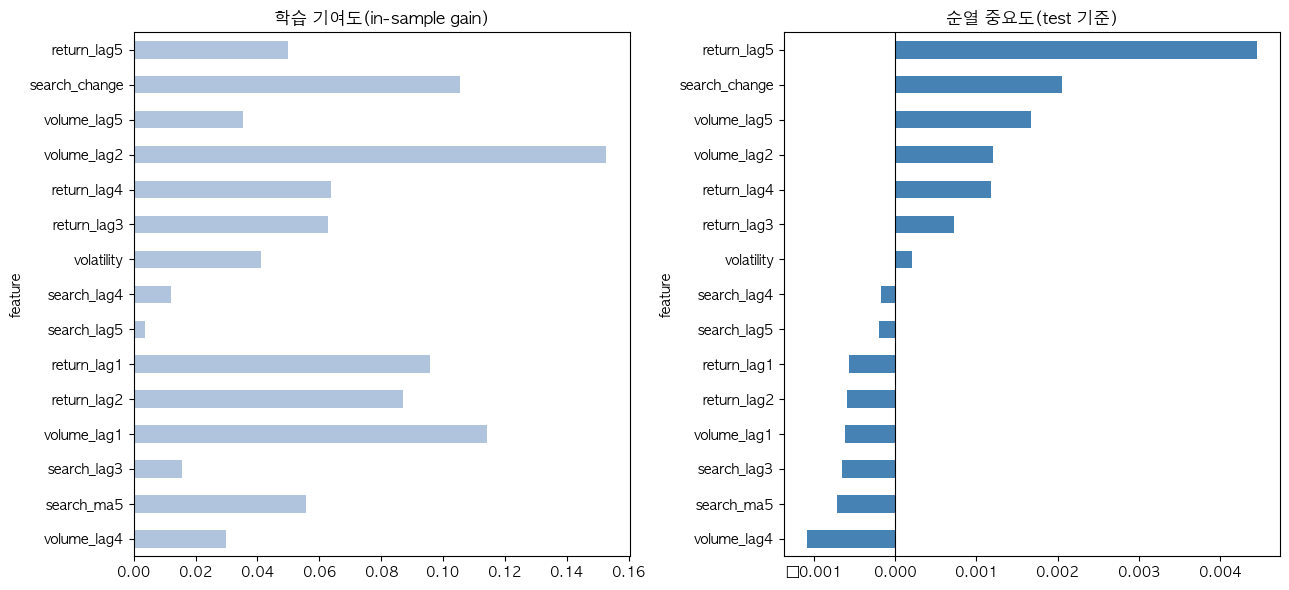

      feature    gain     perm
  search_lag2 0.01614 -0.00256
  search_lag1 0.01535 -0.00145
  volume_lag3 0.04348 -0.00118
  volume_lag4 0.02985 -0.00109
   search_ma5 0.05555 -0.00071
  search_lag3 0.01556 -0.00065
  volume_lag1 0.11434 -0.00061
  return_lag2 0.08701 -0.00059
  return_lag1 0.09562 -0.00057
  search_lag5 0.00374 -0.00020
  search_lag4 0.01216 -0.00017
   volatility 0.04104  0.00021
  return_lag3 0.06274  0.00073
  return_lag4 0.06383  0.00119
  volume_lag2 0.15270  0.00121
  volume_lag5 0.03544  0.00167
search_change 0.10557  0.00205
  return_lag5 0.04988  0.00446


In [ ]:
# 피처 중요도

from sklearn.inspection import permutation_importance

gbr = GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05,
                                subsample=0.8, random_state=42)
gbr.fit(train[all_cols], train["target"])
perm = permutation_importance(gbr, test[all_cols], test["target"], n_repeats=30, 
                              random_state=42, scoring="neg_root_mean_squared_error")
# permutation_importance : test에서 한 피처의 값만 섞음 -> 성능이 얼마나 나빠지는지 계산 -> 섞기 전과의 차이 : 피처의 중요도
# neg ~ error:RMSE는 작을수록 좋으므로 부호를 뒤집어 클수록 좋게 만듦
imp = pd.DataFrame({"feature":all_cols, 
                    "gain":gbr.feature_importances_, # 각 피처가 트리 분기에서 불순도를 얼마나 줄였는지 합산한 값
                    "perm":perm.importances_mean}).sort_values("perm") # importances_mean:중요도30개의 평균

fig, ax = plt.subplots(1, 2, figsize=(13, 6))
imp.set_index("feature")["gain"].tail(15).plot(kind="barh", ax=ax[0], color="lightsteelblue")
# 피처이름을 인덱스로 올림(그래야 막대라벨로 쓰임), 그 상태에서 gain열만 뽑고, 마지막 15개를 남김
# kind="barh":가로막대, ax=ax[0]어느 판에 그릴지 선택
ax[0].set_title("학습 기여도(in-sample gain)")
imp.set_index("feature")["perm"].tail(15).plot(kind="barh", ax=ax[1], color="steelblue")
# 위와같은 방식으로 perm을 그림
ax[1].axvline(0, color="black", lw=0.8)# 0치에 세로선을 그림(왼쪽부분:섞었더니 오히려 성능이 좋아진 피처(해로운 피처))
ax[1].set_title("순열 중요도(test 기준)")
plt.tight_layout(); plt.show() # tight_layout:라벨 잘림을 막음

print(imp.round(5).to_string(index=False))
# 읽는 법 : 왼쪽은 길게 나오는데 오른쪽이 0에 가깝거나 음수 - 그 피처는 학습 데이터에서만 쓰였고, 실제 예측에는 기여하지 못함

\- GBR 피처 중요도를 학습 기여도와 순열 중요도로 나누어 비교하였다. 검색량 피처 7개 중 6개가 순열 중요도에서 음수를 기록했으며, 특히 search_lag1과 search_lag2가 전체 18개 피처 중 최하위 2개였다. 해당 피처를 무작위로 치환했을 때 오히려 검증 오차가 감소함을 의미한다. 

\- 두 지표의 순위는 상당 부분 역전된다. search_ma5는 학습 기여도 0.05555로 상위권이나 순열 중요도는 -0.00071이며, volume_lag1역시 기여도 0.11434(2위) 대비 순열 중요도 -0.00061이다. 학습 데이터에서 빈번히 사용된 피처가 검증 구간에서는 일봔화되지 않았음을 보여준다. 

\- 유일하게 양의 순열 중요도를 보인 검색량 피처는 search_change이나, 해당변수는 주별 검색량을 일별로 전진 대입한 구조상 주 경계 시점에만 0이 아닌 값을 가진다. 검색량의 크기정보보다 주간 갱신 시점을 표시하는 신호로 작동했을 가능성이 있어 해석에 유의가 필요하다. 

\- 전체적으로 순열 중요도의 절대 크기는 최대 0.00446으로 Test RMSE(0.23872)의 1.9%수준에 그쳐, 어떤 피처도 실질적 예측에 기여하지 못했다. 

-<정리> - 결과는 3장의 Granger비유의, 4장의 CAR비유의와 일관된다. 검색량은 익일 수익률에 대한 선행 정보를 담지 않으며, 예측 모형에 투입할 경우 설명력보다는 잡음을 추가한다는 것을 확인할 수 있다. 다만 검증구간 절대오차 상위 3일이 MSE의 약 59%를 차지해, 110일 평가가 소수 극단 시점에 의해 좌우되는 구조적 한계가 있다. 확장창(walk-forward) 검증을 통한 재확인이 필요하다. 

# 5. VAR 다변량 분석

## 5.1 차수 선택 및 추정

dlog_search, log_return, dlog_volume 3변수를 주별 115주로 추정 (검색량, 수익률, 거래량)

In [149]:
weekly["dlog_volume"] = np.log(weekly["volume"]).diff()
print(weekly[["log_return", "dlog_search", "dlog_volume"]].isna().sum())

log_return     0
dlog_search    0
dlog_volume    1
dtype: int64


In [ ]:
from statsmodels.tsa.api import VAR

cols = ["dlog_search", "log_return", "dlog_volume"]
d = weekly[cols].replace([np.inf, -np.inf], np.nan).dropna()
d = (d - d.mean()) / d.std() # 표준화

model = VAR(d)
sel = model.select_order(maxlags=6)
print(pd.DataFrame({"AIC" : sel.aic, "BIC" : sel.bic}, index=["선택차수"]))

print("[BIC차수 선택]")
p = max(1, int(sel.bic)) # BIC차수 선택, max(1, *) : BIC가 0을 고를 경우를 막기 위함
fit = model.fit(p) # 각 방정식을 OLS로 추정
print(f"\n차수 p = {p}, 표본 {len(d)}")
print(f"안정성 : 최소 |근| {np.abs(fit.roots).min():.4f} ({'안정' if fit.is_stable(verbose=False) else '불안정'})") # 안정성 검사
# fit.roots:방정식의 해 z반환, 조건(모든 |z|>1), fit.is_stable:같은 판정을 불리언으로 줌

# 잔차에 남은 자기상관 검정하는 부분(다변량 Ljung-Box검정 (H0:잔차가 백색잡음이다 : 기각 실패 -> 차수 충분)
lb = fit.test_whiteness(nlags=min(10, p+5), adjusted=True)
print(f"잔차 백색잡음 p = {lb.pvalue:.4f}")

# 수익률 방정식 계수, VAR의 세 방정식 중 "수익률" 방정식만 뽑아보는 부분, 계수:(3p + 1)개
# "검색량 과거값이 수익률을 설명하는가?"
# 표준화된 변수이므로 단위가 표준편차, p < 0.05:계수가 0과 다름 / p > 0.05:계수가 0과 구분안됨
print("\n[log_return 방정식]")
print(pd.DataFrame({"계수" : fit.params["log_return"].round(4), 
                    "p" : fit.pvalues["log_return"].round(4)}))

# 참고(거래량 변수 통제)
# VAR내 Granger(전 시차 동시검정), 거래량 통제 후 실시
print("\n****  참고")
g = fit.test_causality("log_return", ["dlog_search"], kind="f")
print(f"dlog_search -> log_return : F={g.test_statistic:.3f}, p={g.pvalue:.4f}")

      AIC  BIC
선택차수    2    0
[BIC차수 선택]

차수 p = 1, 표본 114
안정성 : 최소 |근| 3.1363 (안정)
잔차 백색잡음 p = 0.0743

[log_return 방정식]
                    계수       p
const           0.0040  0.9662
L1.dlog_search -0.0615  0.5887
L1.log_return   0.1096  0.3632
L1.dlog_volume -0.1057  0.3668

****  참고
dlog_search -> log_return : F=0.292, p=0.5890


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)


In [178]:
print(pd.DataFrame({"AIC" : sel.aic, "BIC" : sel.bic}, index=["선택차수"]))
print("[AIC차수 선택]")

p = max(1, int(sel.aic)) # AIC차수 선택, max(1, *) : AIC가 0을 고를 경우를 막기 위함
fit = model.fit(p) # 각 방정식을 OLS로 추정
print(f"\n차수 p = {p}, 표본 {len(d)}")
print(f"안정성 : 최소 |근| {np.abs(fit.roots).min():.4f} ({'안정' if fit.is_stable(verbose=False) else '불안정'})") # 안정성 검사
# fit.roots:방정식의 해 z반환, 조건(모든 |z|>1), fit.is_stable:같은 판정을 불리언으로 줌

# 잔차에 남은 자기상관 검정하는 부분(다변량 Ljung-Box검정 (H0:잔차가 백색잡음이다 : 기각 실패 -> 차수 충분)
lb = fit.test_whiteness(nlags=min(10, p+5), adjusted=True)
print(f"잔차 백색잡음 p = {lb.pvalue:.4f}")

# 수익률 방정식 계수, VAR의 세 방정식 중 수익률 방정식만 뽑아보는 부분
# "검색량 과거값이 수익률을 설명하는가?"
print("\n[log_return 방정식]")
print(pd.DataFrame({"계수" : fit.params["log_return"].round(4), 
                    "p" : fit.pvalues["log_return"].round(4)}))

# 참고(거래량 변수 통제)
# VAR내 Granger(전 시차 동시검정), 거래량 통제 후 실시
print("\n****  참고")
g = fit.test_causality("log_return", ["dlog_search"], kind="f")
print(f"dlog_search -> log_return : F={g.test_statistic:.3f}, p={g.pvalue:.4f}")

      AIC  BIC
선택차수    2    0
[AIC차수 선택]

차수 p = 2, 표본 114
안정성 : 최소 |근| 1.8328 (안정)
잔차 백색잡음 p = 0.2031

[log_return 방정식]
                    계수       p
const           0.0089  0.9269
L1.dlog_search -0.0609  0.6095
L1.log_return   0.1240  0.3146
L1.dlog_volume -0.1225  0.3350
L2.dlog_search  0.0482  0.6842
L2.log_return  -0.1203  0.3313
L2.dlog_volume  0.0363  0.7701

****  참고
dlog_search -> log_return : F=0.266, p=0.7665


\- VAR차수 선택에서는 BIC는 0, AIC는 2를 지시하였다. BIC가 0을 선택한 것은 세 변수의 시차구조가 정보량 기준으로 정당화 되지 않음을 의미한다. 잔차 자기상관 진단을 고려하여 AIC 기준 p=2를 채택하였다. 특성근의 최소값이 1.8328으로 안정성 조건을 충족하며 잔차의 백색잡음 가설도 p 값 0.2031로 5%수준에서 기각되지 않았다. 

\- 수익률 방정식의 계수는 모두 비유의하다. 검색량 시차 계수는 L1 -0.0609(p=0.6095), L2 0.0482(p=0.6842)로 부호가 일관되지 않으며 통계적 유의성도 없다. 수익률 자기 시차(L1 0.1240, L2 -0.1203)와 거래량 시차(L1 -0.1225, L20.0363)역시 p값이 0.05 이상으로 모두 비유의하다. 거래량을 통한 VAR내 Granger검정에서도 F통계량 0.266, p값 0.7701로 검색량의 수익률 예측력은 확인되지 않았다. 

\- 이는 3장의 2변수 Granger 결과와 일치하며, 거래량이라는 교란 요인을 통제한 뒤에도 결론이 유지됨을 보여준다. 아울러 수익률 자기 시차조차 유의하지 않다는 점은 5장에서 관측된 예측 모형의 성능 부진이 검색량 피처의 문제가 아니라 익일 수익률 자체의 예측 불가능성에 기인함을 시사한다. 

## 5.2 IRF & FEVD

/var/folders/fp/x215k2mn3hz64lx20kdfw0cr0000gn/T/ipykernel_61564/10019237.py:6: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AppleGothic.
  plt.tight_layout(); plt.savefig("fig_6_irf.png"); plt.show()
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


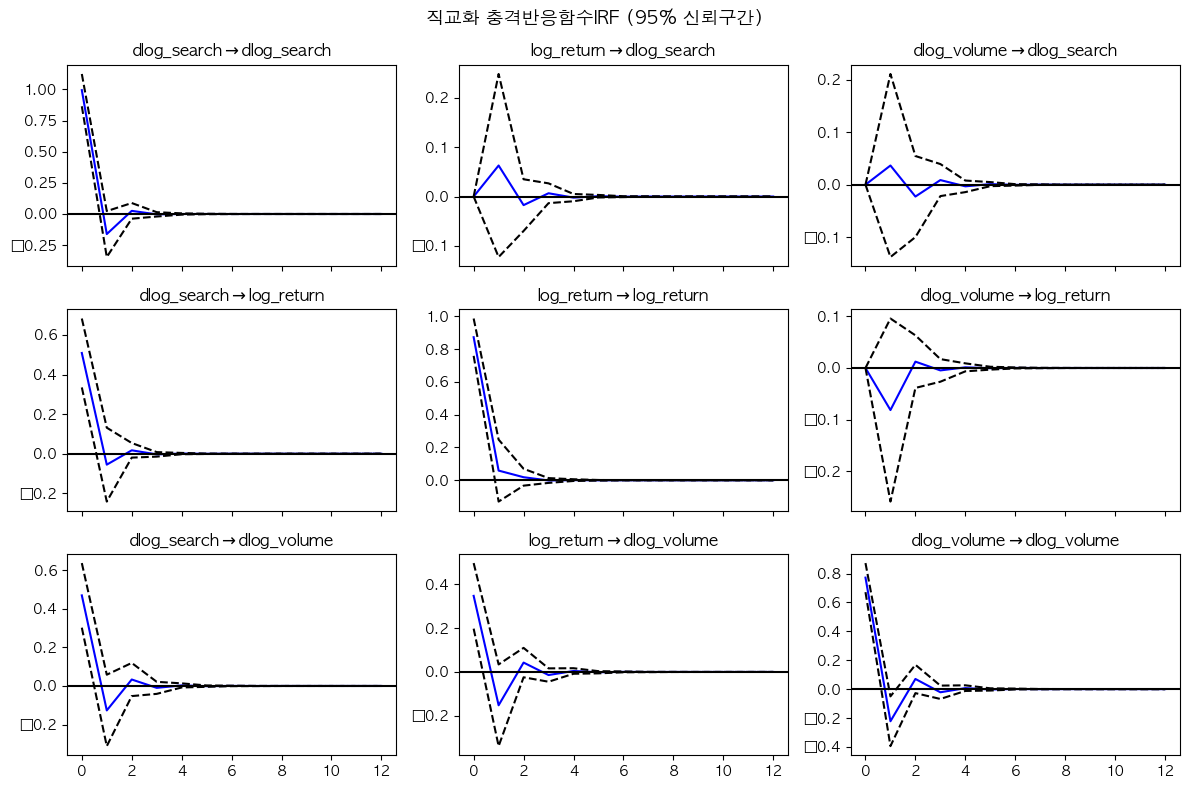

In [165]:
PERIODS = 12 # 12주 약 3개월

irf = fit.irf(PERIODS)
fig = irf.plot(orth=True, signif=0.05, figsize=(12, 8))
fig.suptitle("직교화 충격반응함수IRF (95% 신뢰구간)", fontsize=13)
plt.tight_layout(); plt.savefig("fig_6_irf.png"); plt.show()

\- 검색량 충격에 대한 수익률의 반응은 동시점(h=0)에서 0.51로 유의하나, h=1에서 -0.05로 하락하며 신뢰구간이 0을 포함한다. h=2 이후로는 반응이 0에 수렴하여, 검색량 충격이 후속 수익률에 지속적 영향을 남기지 않음을 보여준다. 

\- 다만 h=0의 유의한 반응은 촐레스키 분해에서 검색량을 첫번째 변수로 배열한 식별 가정에 기인한다. 변수 순서를 변경하면 동시점 반응은 소멸하므로 이를 검색량에서 수익률로의 인과로 해석할 수 없다. 이는 3장 교차상관에서 lag0에서만 유의한 상관이 관측된 것과 동일한 패턴이다. 

\- 수익률 자기충격 역시 h=1에서 0.06으로 급감하고 신뢰구간이 0을 포함하여, 주간 수익률에 지속적 시차구조가 존재하지 않음을 확인할 수 있다. 

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


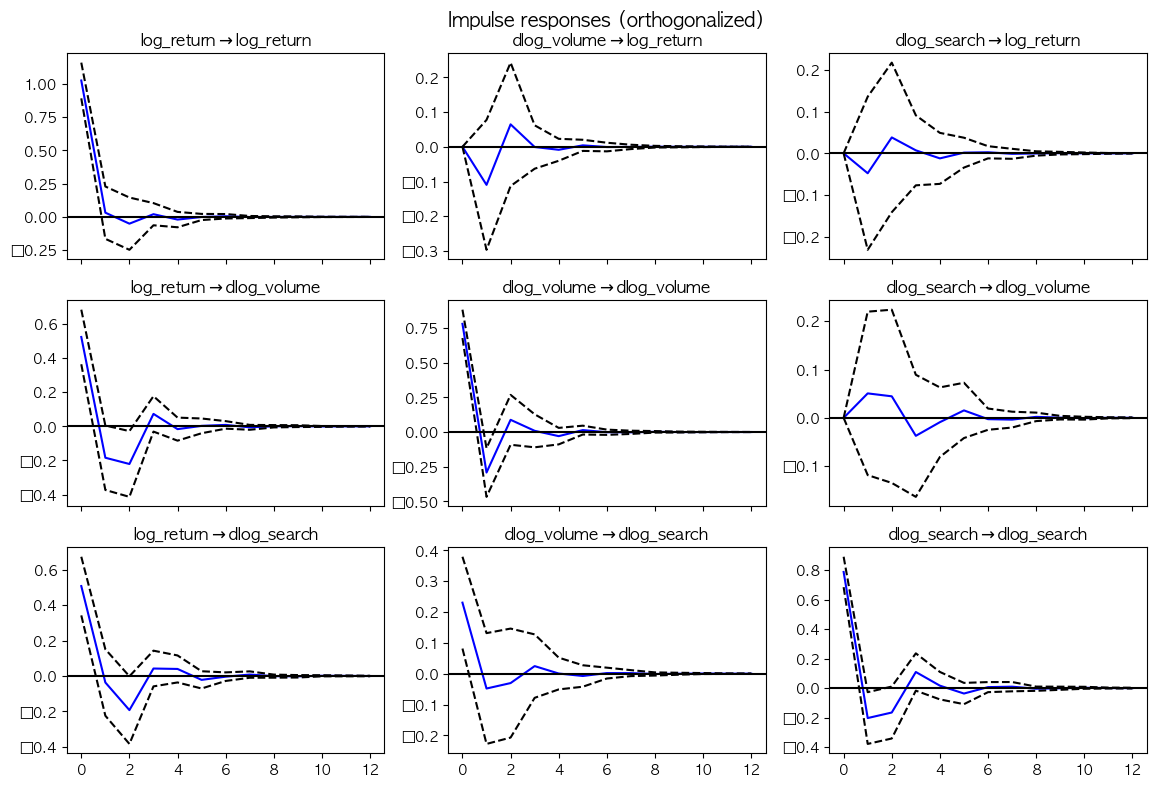

In [ ]:
# 촐레스키 분해에서 검색량을 마지막에 배치
alt = weekly[["log_return","dlog_volume","dlog_search"]].dropna()
alt = (alt - alt.mean())/alt.std()
fit_alt = VAR(alt).fit(2)
fit_alt.irf(12).plot(orth=True, signif=0.05, figsize=(12,8))
plt.show()

\- 촐레스키 분해의 변수 순서를 검색량 우선(dlog_search -> log_return -> dlog_volume)에서 수익률 우선(log_return -> dlog_volume -> dlog_search)으로 변경하여 강건성을 확인하였다. 

\- 원래 순서에서 h=0의 검색량 -> 수익률 반응은 0.51로 유의했으나, 순서 변경 시 정확히 0이 되고 대신 수익률 -> 검색량 반응이 h=0에서 0.51로 나타난다. 동일한 동시점 상관이 배열 순서에 따라 인과 방향이 뒤바뀌어 배정되는 것으로, h=0 반응을 검색량에서 수익률로의 영향으로 해석할 근거가 없음을 보여준다.

\- 두 순서 모두에서 h >= 1의 반응은 신뢰구간이 0을 포함하며 h=2이후에 0에 수렴한다. 식별 가정과 무관하게 검색량 충격은 후속 수익률에 지속적 영향을 남기지 않는다. 

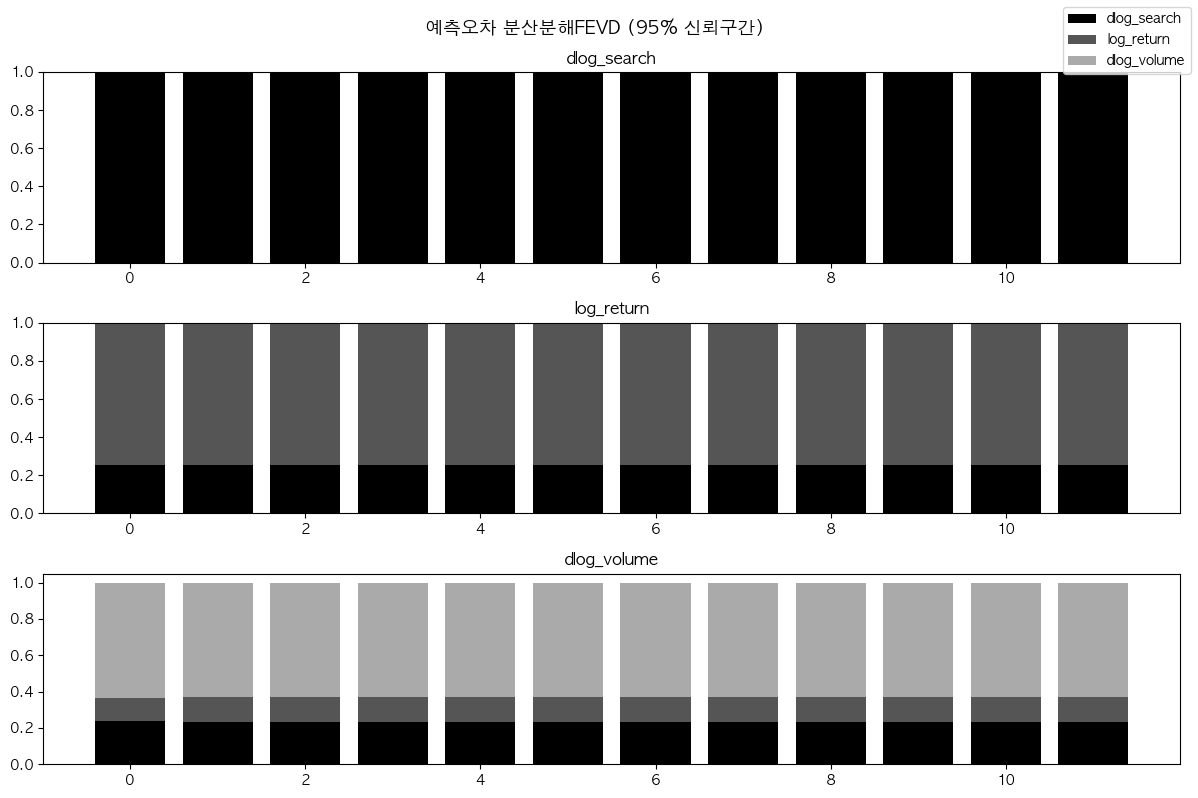

[log_return 예측오차 분산 중 각 충격의 기여율]
      dlog_search  log_return  dlog_volume
h=1        0.2539      0.7461       0.0000
h=2        0.2536      0.7400       0.0064
h=3        0.2537      0.7398       0.0066
h=4        0.2537      0.7397       0.0066
h=5        0.2537      0.7397       0.0066
h=6        0.2537      0.7397       0.0066
h=7        0.2537      0.7397       0.0066
h=8        0.2537      0.7397       0.0066
h=9        0.2537      0.7397       0.0066
h=10       0.2537      0.7397       0.0066
h=11       0.2537      0.7397       0.0066
h=12       0.2537      0.7397       0.0066


In [ ]:
fevd = fit.fevd(PERIODS)
fig = fevd.plot(figsize=(12, 8))
fig.suptitle("예측오차 분산분해FEVD (95% 신뢰구간)", fontsize=13)
plt.tight_layout(); plt.savefig("fig_6_fevd.png"); plt.show()

# 수익률 분산분해 수치
i = fit.names.index("log_return")
tab = pd.DataFrame(fevd.decomp[i], columns=fit.names, 
                   index=[f"h={h+1}" for h in range(PERIODS)])
print("[log_return 예측오차 분산 중 각 충격의 기여율]")
print(tab.round(4))

In [171]:
j = fit_alt.names.index("log_return")
tab_alt = pd.DataFrame(fit_alt.fevd(12).decomp[j], columns=fit_alt.names,
                        index=[f"h={h+1}" for h in range(12)])
print(tab_alt.round(4))

      log_return  dlog_volume  dlog_search
h=1       1.0000       0.0000       0.0000
h=2       0.9865       0.0113       0.0022
h=3       0.9814       0.0151       0.0035
h=4       0.9813       0.0151       0.0036
h=5       0.9811       0.0152       0.0037
h=6       0.9811       0.0152       0.0037
h=7       0.9811       0.0152       0.0037
h=8       0.9811       0.0152       0.0037
h=9       0.9811       0.0152       0.0037
h=10      0.9811       0.0152       0.0037
h=11      0.9811       0.0152       0.0037
h=12      0.9811       0.0152       0.0037


\- 검색량 우선 배열의 FEVD에서 수익률 예측오차 분산의 25.39%(h=1)가 검색량 충격에, 74.61%가 자기 충격에 귀속된다. 거래량 기여는 0.66%로 미미하다. 이 비율은 h=2 이후 25.37%에서 고정되어 예측 시계와 무관하게 일정한데, 시차계수가 모두 비유의하여 충격이 시간에 따라 전이되지 않기 때문이다. 

\- 다만 이 25%는 전적으로 동시점 분해에서 발생하며 촐레스키 순서에서 검색량을 첫 번째로 배열한 식별 가저의 산물이다. 변수 순서를 수익률 우선으로 변경하면 해당 기여율은 h=1에서 0.00%, h=12에서 0.37%에 그친다. 동일한 데이터와 차수에서 배열만 변경했음에도 기여율이 약 68배 차이를 보인다. 

\- IRF와 FEVD 결과가 식별 가정에 전적으로 의존한다는 점은, 동시점 상관만 존재하고 시차 관계가 부재한 본 표본 구조를 반영한다. 동시점 상관은 어느 방향으로도 배정될 수 있으므로 인과 해석의 근거가 되지 못한다. 

In [ ]:
# 참고
r = stock_data["return"]
print(f"첨도 {r.kurtosis():.1f} / 연율변동성 {r.std()*np.sqrt(252)*100:.0f}%")

첨도 95.7 / 연율변동성 295%
